In [4]:
#Importando as bibliotecas
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib as mat
import matplotlib.pyplot as plt
import kagglehub

In [3]:
# Download latest version
path = kagglehub.dataset_download("sijovm/used-cars-data-from-ebay-kleinanzeigen")

print("Path to dataset files:", path)

100%|██████████| 17.2M/17.2M [00:00<00:00, 99.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sijovm/used-cars-data-from-ebay-kleinanzeigen/versions/1


In [6]:
#Criando o dataframe
cars = pd.read_csv(f'{path}/autos.csv', encoding='latin-1')
print(cars.shape)

(371528, 20)


In [8]:
#Criando o dataframe
cars = pd.read_csv(f'{path}/autos.csv',encoding="latin-1")
print(cars.shape)
cars.head(-10)

(371528, 20)


,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,2016-03-24 11:52:17,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,0,golf,150000,0,benzin,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,190,NaN,125000,5,diesel,audi,ja,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,163,grand,125000,8,diesel,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,75,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,69,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371513,2016-03-21 15:36:22,Seat_Leon_1.9_TDI_4/5_Tueren,privat,Angebot,4400,control,limousine,2008,manuell,105,leon,150000,7,diesel,seat,nein,2016-03-21 00:00:00,0,45896,2016-04-06 15:45:01
371514,2016-04-04 11:45:16,Renault_1_4_ltr.16_V_Megane_Cabrio,privat,Angebot,999,control,cabrio,2000,manuell,95,megane,150000,4,benzin,renault,NaN,2016-04-04 00:00:00,0,88477,2016-04-06 12:44:52
371515,2016-03-09 11:36:55,Skoda_Fabia_Kombi_1.4,privat,Angebot,1690,test,kombi,2004,manuell,55,fabia,150000,4,benzin,skoda,NaN,2016-03-09 00:00:00,0,18246,2016-04-04 08:15:30
371516,2016-04-04 09:57:12,Volkswagen_Lupo_1.0,privat,Angebot,1490,control,kleinwagen,1998,manuell,50,lupo,150000,9,benzin,volkswagen,nein,2016-04-04 00:00:00,0,48653,2016-04-06 11:17:13


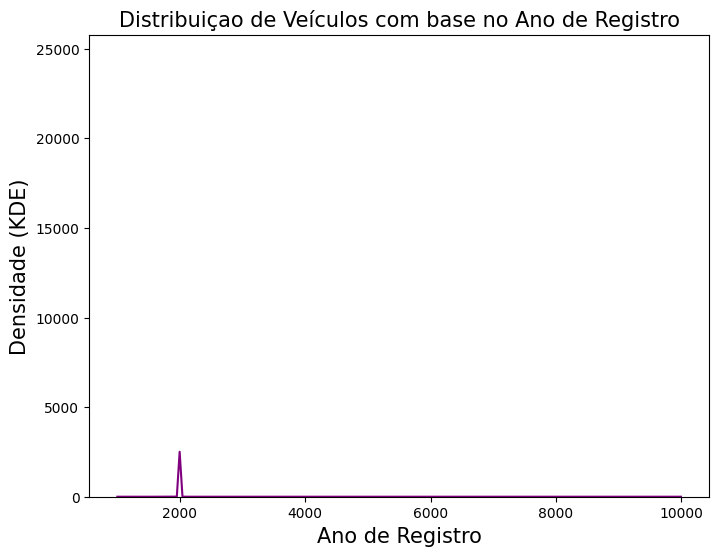

In [9]:
# Crie um Plot com a Distribuição de Veículos com base no Ano de Registro
fig, ax = plt.subplots(figsize=(8,6))
sb.histplot(cars["yearOfRegistration"], color="purple",kde=True, ax=ax)
ax.set_title('Distribuiçao de Veículos com base no Ano de Registro', fontsize= 15)
plt.ylabel("Densidade (KDE)", fontsize= 15)
plt.xlabel("Ano de Registro", fontsize= 15)
plt.show()

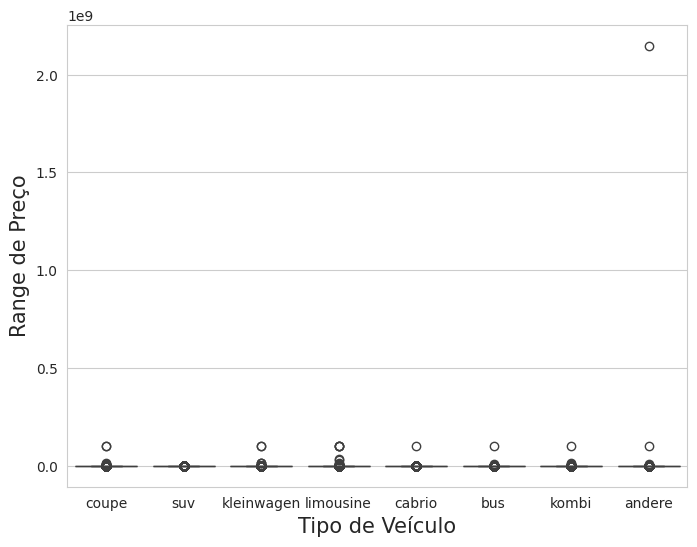

In [10]:
# Crie um Boxplot para avaliar os outliers
sb.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(8,6))
sb.boxplot(x="vehicleType", y="price", data=cars)
ax.xaxis.set_label_text("Tipo de Veículo", fontsize= 15)
ax.yaxis.set_label_text("Range de Preço", fontsize= 15)
plt.show()

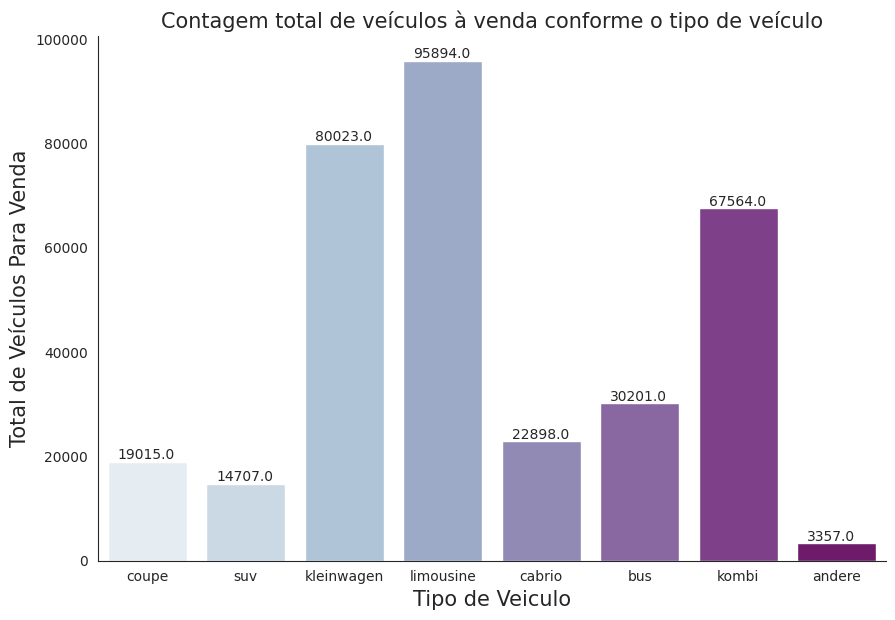

In [21]:
# Crie um Count Plot que mostre o numero de veículos pertencentes a cada categoria
sb.set_style("white")
graf = sb.catplot(x="vehicleType", data=cars, kind="count", hue="vehicleType", palette="BuPu", height=6, aspect=1.5, legend=False)
graf.ax.xaxis.set_label_text("Tipo de Veiculo", fontsize= 15)
graf.ax.yaxis.set_label_text("Total de Veículos Para Venda", fontsize= 15)
graf.ax.set_title("Contagem total de veículos à venda conforme o tipo de veículo", fontsize= 15)

# para mostrar as contagens na parte superior da barra
for p in graf.ax.patches:
    graf.ax.annotate((p.get_height()), (p.get_x()+0.1, p.get_height()+500))

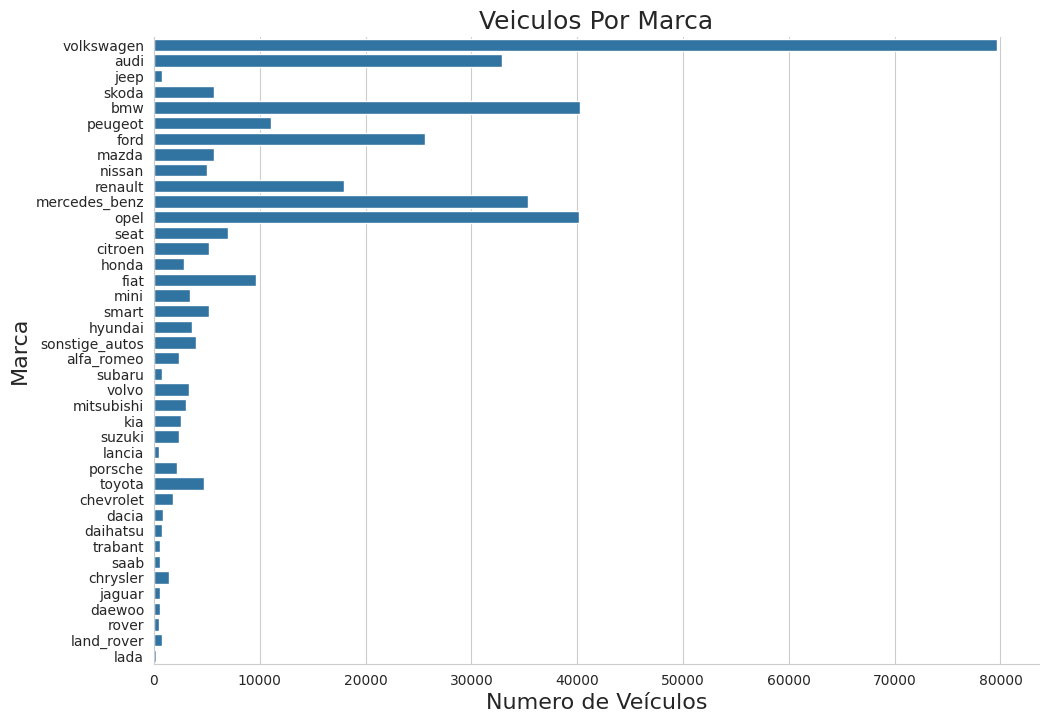

In [13]:
# Crie um Plot que mostre o número de veículos pertencentes a cada marca
sb.set_style("whitegrid")
graf = sb.catplot(y="brand", data=cars, kind="count",height=7, aspect=1.5)
graf.ax.set_title("Veiculos Por Marca", fontdict={'size':18})
graf.ax.xaxis.set_label_text("Numero de Veículos", fontdict= {'size' :16})
graf.ax.yaxis.set_label_text("Marca", fontdict= {'size':16})
plt.show()

/tmp/ipykernel_17723/1965146095.py:5: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sb.barplot(x="vehicleType", y="price",hue="gearbox", palette=colors, data=cars)


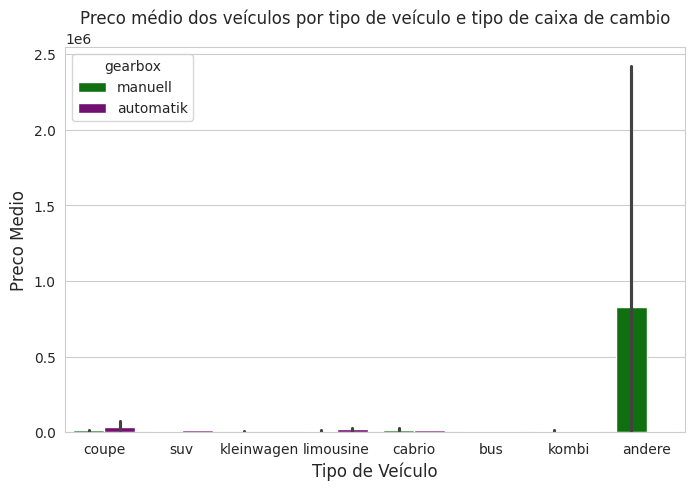

In [14]:
# Crie um Plot com o Preço médio dos veículos
#com base no tipo de veículo, bem como no tipo de caixa de câmbio
fig, ax = plt.subplots(figsize=(8,5))
colors = ["green", "purple","yellow"]
sb.barplot(x="vehicleType", y="price",hue="gearbox", palette=colors, data=cars)
ax.set_title("Preco médio dos veículos por tipo de veículo e tipo de caixa de cambio", fontdict= {'size':12})
ax.xaxis.set_label_text("Tipo de Veículo", fontdict= {'size' :12})
ax.yaxis.set_label_text("Preco Medio",fontdict= {'size':12})
plt.show()

/tmp/ipykernel_17723/3605670135.py:4: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sb.barplot(x="gearbox", y="price",hue="seller", palette=colors, data=cars)


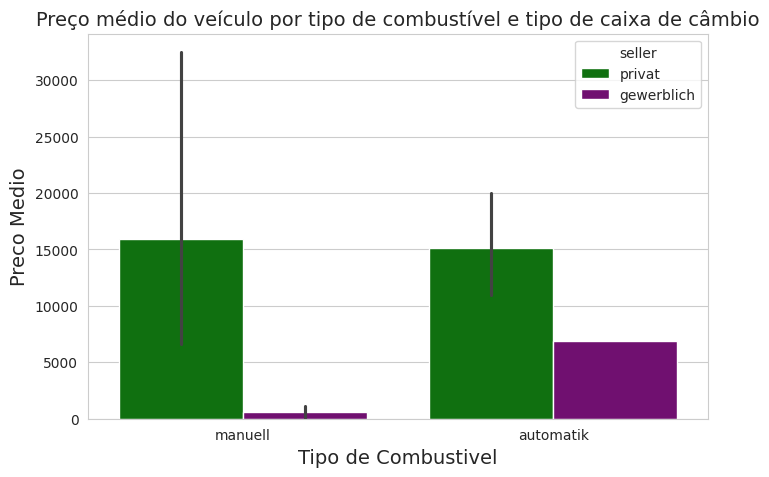

In [15]:
# Criar um Barplot com o Preço médio do veículo por tipo de combustível e tipo de caixa de câmbio
fig, ax = plt.subplots(figsize=(8,5))
colors = ["green", "purple","yellow"]
sb.barplot(x="gearbox", y="price",hue="seller", palette=colors, data=cars)
ax.set_title("Preço médio do veículo por tipo de combustível e tipo de caixa de câmbio", fontsize= 14)
ax.xaxis.set_label_text("Tipo de Combustivel",fontsize= 14)
ax.yaxis.set_label_text("Preco Medio",fontsize= 14)
plt.show()

In [26]:
# Calculando a média de preço por marca e por veículo

list_of_dfs = [] # Usando uma lista para armazenar os DataFrames parciais

for b in list(cars["brand"].unique()):
    for v in list(cars["vehicleType"].unique()):
        z = cars[(cars["brand"] == b) & (cars["vehicleType"] == v)]["price"].mean()
        # Adicionando o DataFrame parcial à lista
        list_of_dfs.append(pd.DataFrame({'brand':b,
                                         'vehicleType':v ,
                                         'avgPrice':z}, index=[0]))

# Concatenando todos os DataFrames da lista em um único DataFrame
mv = pd.concat(list_of_dfs, ignore_index=True)

mv["avgPrice"] = mv["avgPrice"].fillna(0)
mv["avgPrice"].isnull().value_counts()
mv["avgPrice"] = mv["avgPrice"].astype(int)
mv.head()
mv.head(-10)

,brand,vehicleType,avgPrice
0,volkswagen,NaN,0
1,volkswagen,coupe,14854
2,volkswagen,suv,15898
3,volkswagen,kleinwagen,9261
4,volkswagen,limousine,10849
...,...,...,...
345,land_rover,kleinwagen,0
346,land_rover,limousine,875
347,land_rover,cabrio,2675
348,land_rover,bus,0


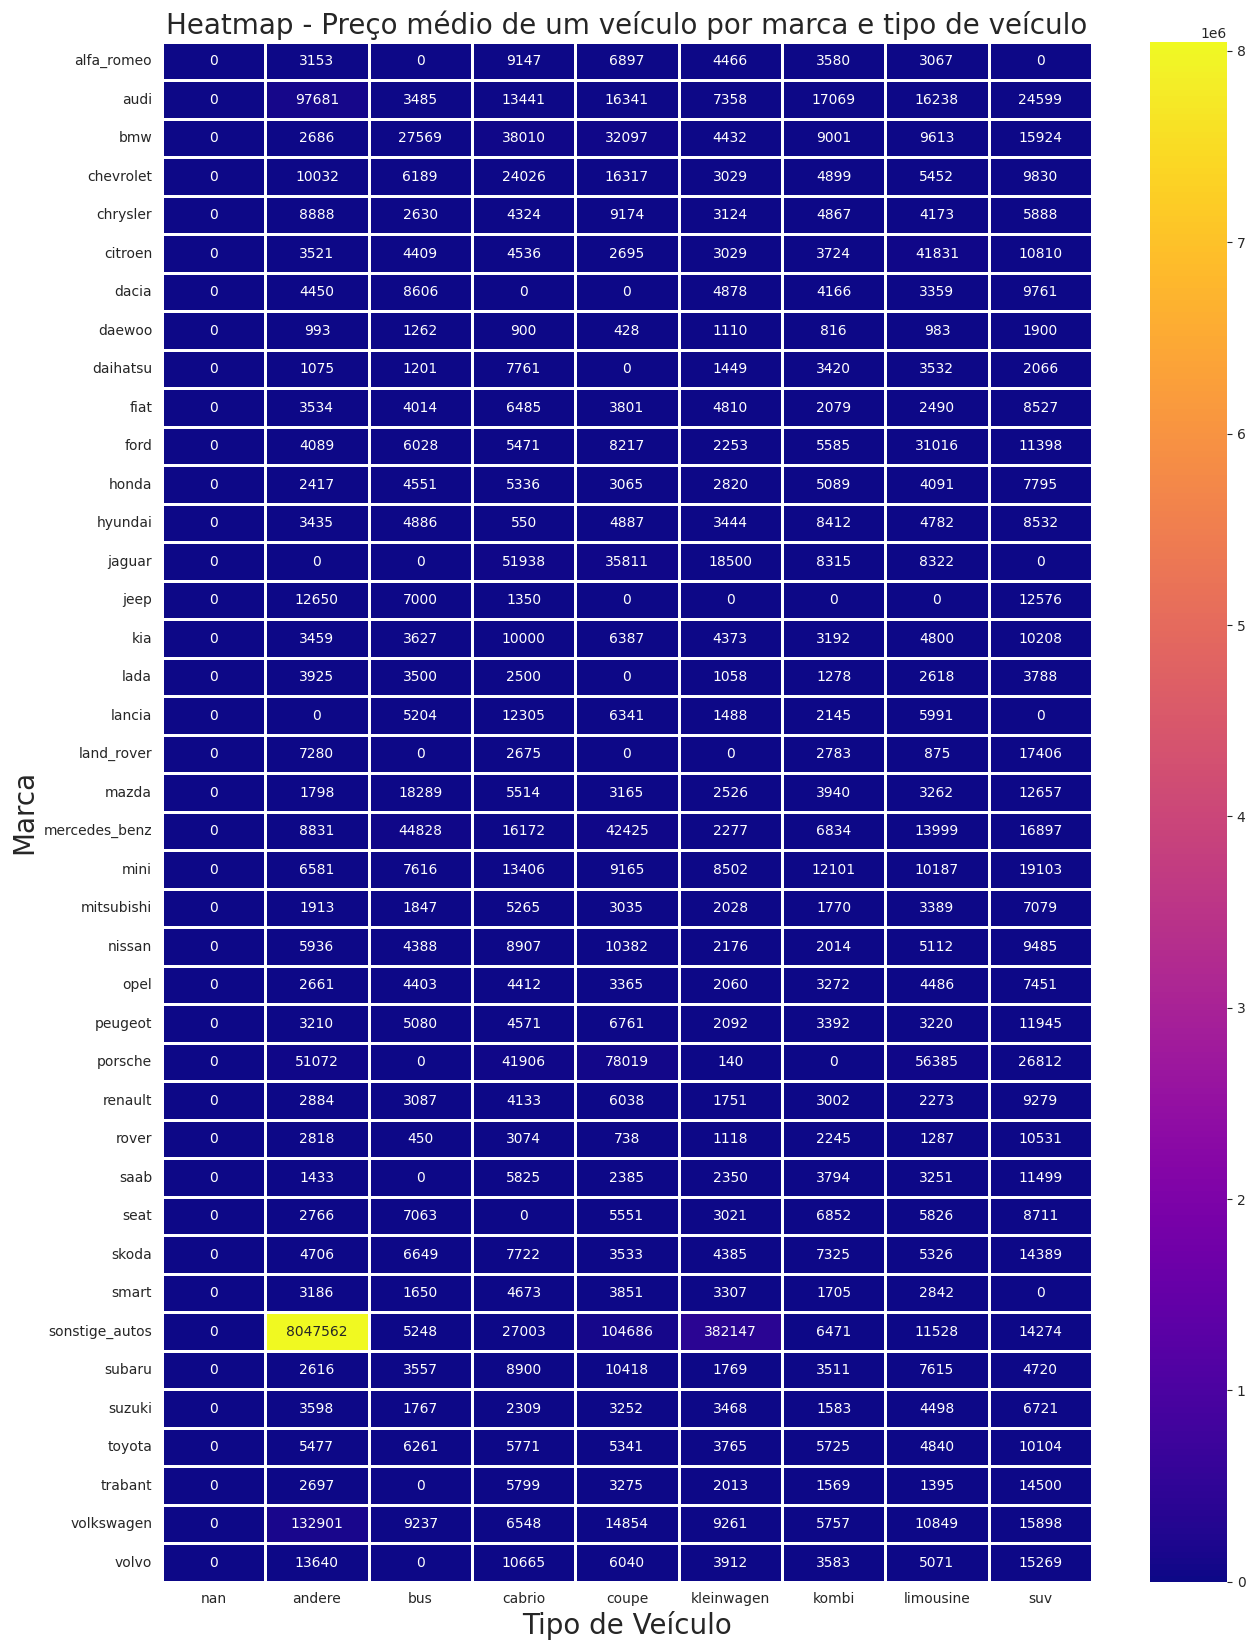

In [29]:
#Criando um Heatmap com Preço médio de um veículo por marca, bem como tipo de veículo
tri = mv.pivot(index="brand", columns="vehicleType", values="avgPrice")
fig, ax = plt.subplots(figsize=(15,20))
sns.heatmap(tri,linewidths=1,cmap="plasma",annot=True, ax=ax, fmt="d")
ax.set_title("Heatmap - Preço médio de um veículo por marca e tipo de veículo",fontsize=20)
ax.xaxis.set_label_text("Tipo de Veículo",fontsize=20)
ax.yaxis.set_label_text("Marca",fontsize=20)
plt.show()